In [1]:
import sys
print(sys.executable)

/home/omareiza-2023/Documentos/etl-cats/.venv/bin/python


# 📊 Análisis de Regresión Lineal — Razas de Gatos
**Proyecto ETL — CORHUILA | Oscar Areiza**

Este notebook implementa modelos de regresión lineal simple y múltiple sobre los datos extraídos de **TheCatAPI** y almacenados en **Supabase (PostgreSQL)**.

**Preguntas que responde este análisis:**
- ¿Puede predecirse la longevidad de un gato a partir de su nivel de energía?
- ¿Qué características (energía, peso, inteligencia, social, adaptabilidad) tienen mayor impacto sobre la vida promedio?
- ¿Existe relación entre el peso y el nivel de energía?
- ¿Los supuestos de normalidad y homocedasticidad se cumplen en los datos de razas?

---
## Fase 1: Importaciones

In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor de base de datos reutilizando database.py del proyecto
from scripts.database import engine

# Estilo visual consistente
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ Librerías importadas correctamente')
print(f'   pandas      {pd.__version__}')
print(f'   numpy       {np.__version__}')
print(f'   seaborn     {sns.__version__}')
print(f'   statsmodels {sm.__version__}')

2026-04-07 15:52:49.880 
  command:

    streamlit run /home/omareiza-2023/Documentos/etl-cats/.venv/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]


✅ Librerías importadas correctamente
   pandas      2.3.3
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


---
## Fase 2: Carga de datos desde Supabase

In [2]:
# ── CELDA 2: Carga de datos desde Supabase ────────────────────
QUERY = """
SELECT
    r.id              AS raza_id,
    r.nombre_raza,
    r.origen,
    r.vida_anos,
    r.peso_kg,
    r.adaptabilidad,
    r.nivel_energia,
    r.inteligencia,
    r.social_humanos,
    COUNT(i.id)       AS total_imagenes
FROM razas r
LEFT JOIN imagenes i ON i.raza_id = r.id
GROUP BY
    r.id, r.nombre_raza, r.origen,
    r.vida_anos, r.peso_kg,
    r.adaptabilidad, r.nivel_energia,
    r.inteligencia, r.social_humanos
ORDER BY r.nombre_raza
"""

df = pd.read_sql(QUERY, engine)

print(f'✅ Datos cargados exitosamente desde Supabase')
print(f'   Filas    : {df.shape[0]:,}')
print(f'   Columnas : {df.shape[1]}')
print(f'\n📋 Primeras filas:')
df.head(10)

✅ Datos cargados exitosamente desde Supabase
   Filas    : 66
   Columnas : 10

📋 Primeras filas:


,raza_id,nombre_raza,origen,vida_anos,peso_kg,adaptabilidad,nivel_energia,inteligencia,social_humanos,total_imagenes
0,abys,Abyssinian,Egypt,14.5,4.0,5,5,5,5,15
1,aege,Aegean,Greece,10.5,4.0,5,3,3,4,5
2,abob,American Bobtail,United States,13.0,5.0,5,3,5,3,6
3,acur,American Curl,United States,14.0,3.5,5,3,3,3,8
4,asho,American Shorthair,United States,16.0,5.5,5,3,3,4,4
5,awir,American Wirehair,United States,16.0,5.5,5,3,3,3,4
6,amau,Arabian Mau,United Arab Emirates,13.0,5.5,5,4,3,3,6
7,amis,Australian Mist,Australia,14.0,5.0,5,4,4,4,4
8,bali,Balinese,United States,12.5,3.5,5,5,5,5,12
9,bamb,Bambino,United States,13.0,3.0,5,5,5,3,9


In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print('=' * 55)
print('  INFORMACIÓN GENERAL DEL DATASET')
print('=' * 55)
print(df.info())

print('\n⚠️  Valores nulos por columna:')
print(df.isnull().sum())

print(f'\n🌍 Razas por país de origen (top 10):')
print(df['origen'].value_counts().head(10))

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   raza_id         66 non-null     object 
 1   nombre_raza     66 non-null     object 
 2   origen          66 non-null     object 
 3   vida_anos       66 non-null     float64
 4   peso_kg         66 non-null     float64
 5   adaptabilidad   66 non-null     int64  
 6   nivel_energia   66 non-null     int64  
 7   inteligencia    66 non-null     int64  
 8   social_humanos  66 non-null     int64  
 9   total_imagenes  66 non-null     int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 5.3+ KB
None

⚠️  Valores nulos por columna:
raza_id           0
nombre_raza       0
origen            0
vida_anos         0
peso_kg           0
adaptabilidad     0
nivel_energia     0
inteligencia      0
social_humanos    0
total_imagenes    0
dtype: int64

🌍 Razas po

---
## Fase 3: EDA — Análisis Exploratorio de Datos

In [4]:
# ── CELDA 4: Limpieza y estadísticas descriptivas ─────────────
VARS_NUM = ['vida_anos', 'peso_kg', 'adaptabilidad',
            'nivel_energia', 'inteligencia', 'social_humanos']

df_limpio = df.dropna(subset=VARS_NUM).copy()

print(f'Filas originales : {len(df)}')
print(f'Filas limpias    : {len(df_limpio)}')
print(f'Filas eliminadas : {len(df) - len(df_limpio)}')

print('\n📊 ESTADÍSTICAS DESCRIPTIVAS')
desc = df_limpio[VARS_NUM].describe().round(2)
print(desc)

Filas originales : 66
Filas limpias    : 66
Filas eliminadas : 0

📊 ESTADÍSTICAS DESCRIPTIVAS
       vida_anos  peso_kg  adaptabilidad  nivel_energia  inteligencia  \
count      66.00    66.00          66.00          66.00         66.00   
mean       13.73     4.71           4.82           3.89          4.38   
std         1.59     1.07           0.58           1.05          0.89   
min        10.50     3.00           2.00           1.00          3.00   
25%        13.00     4.00           5.00           3.00          3.00   
50%        13.50     4.75           5.00           4.00          5.00   
75%        14.50     5.50           5.00           5.00          5.00   
max        19.00     7.50           5.00           5.00          5.00   

       social_humanos  
count           66.00  
mean             4.12  
std              0.85  
min              3.00  
25%              3.00  
50%              4.00  
75%              5.00  
max              5.00  


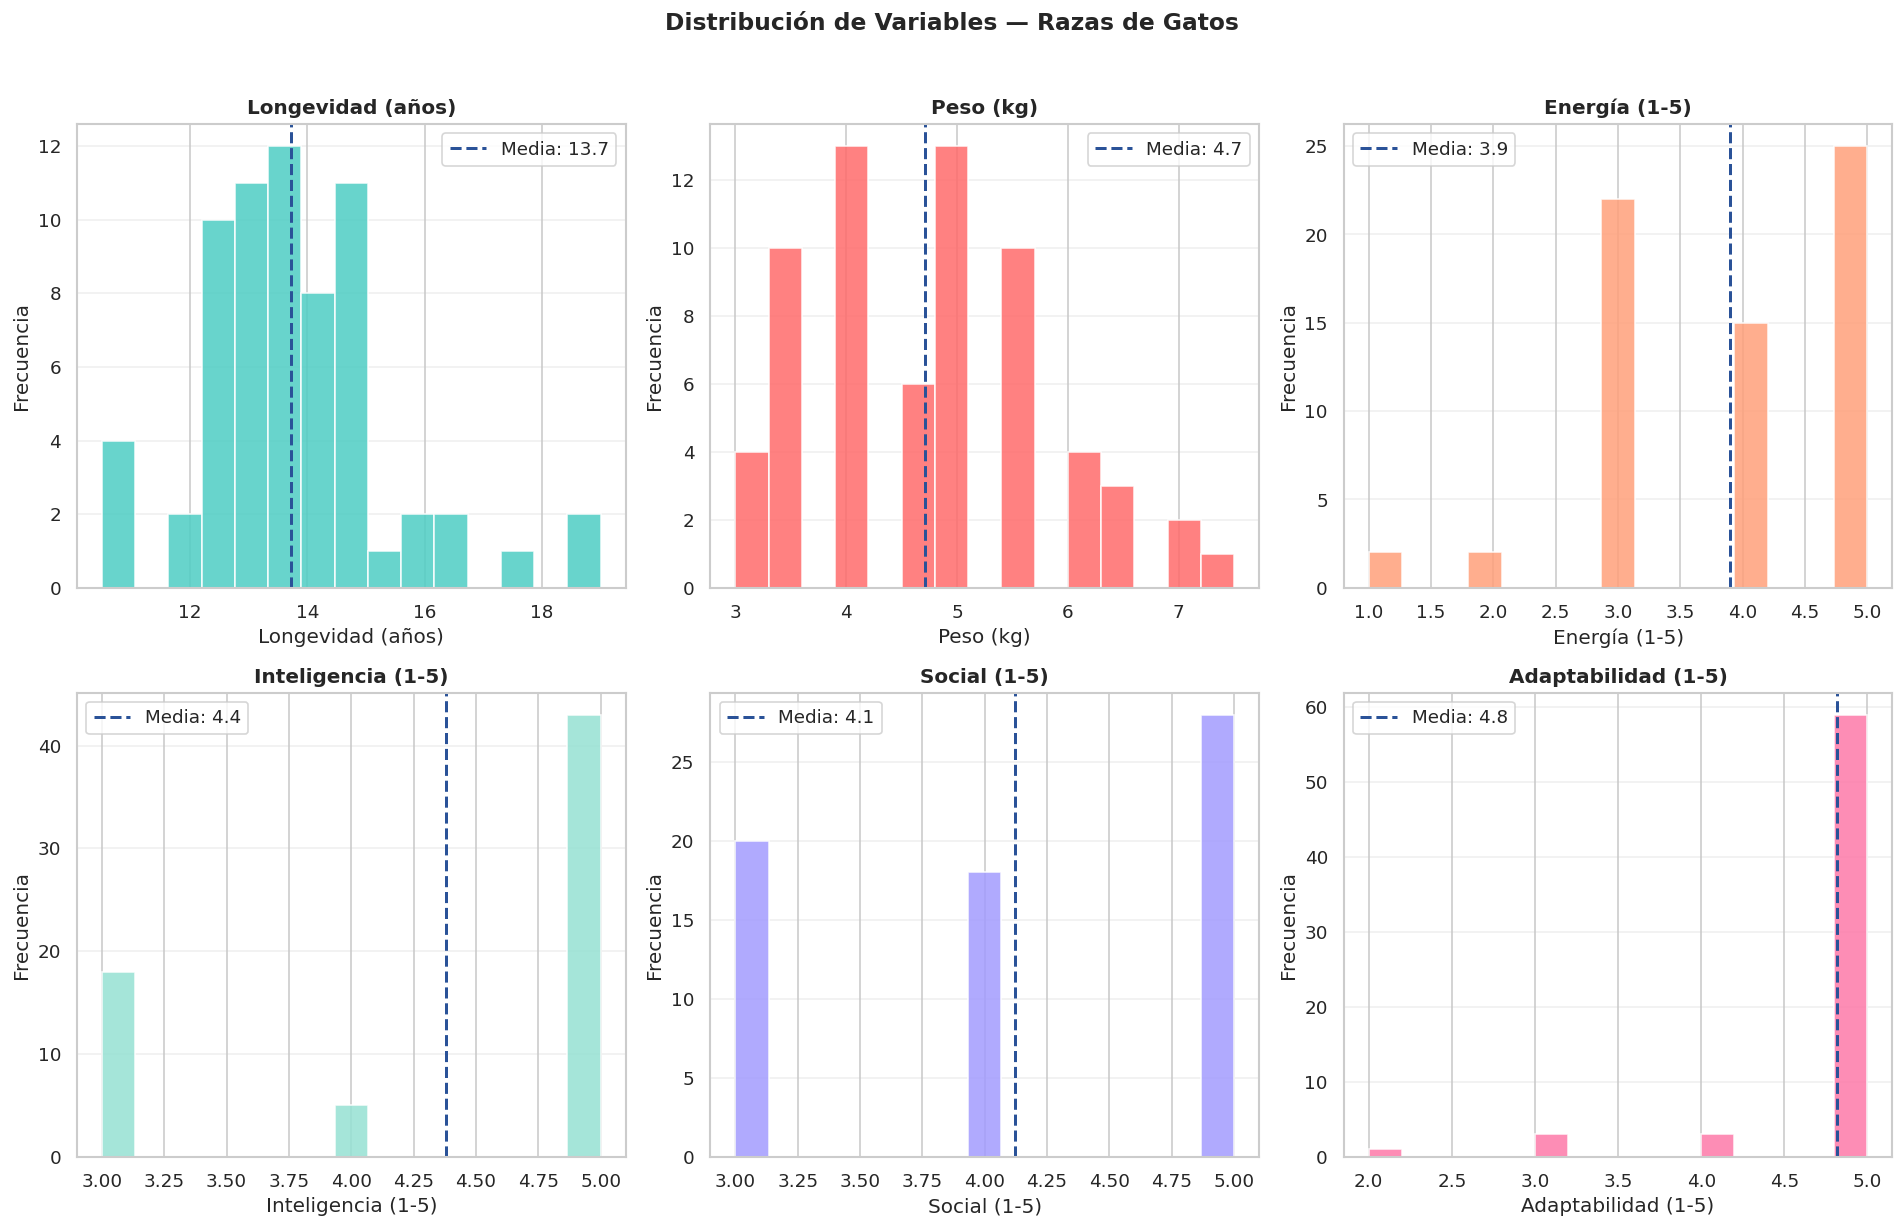

In [5]:
# ── CELDA 5: Histogramas de distribución ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Variables — Razas de Gatos',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'vida_anos':      ('Longevidad (años)',    '#4ecdc4'),
    'peso_kg':        ('Peso (kg)',             '#ff6b6b'),
    'nivel_energia':  ('Energía (1-5)',         '#ffa07a'),
    'inteligencia':   ('Inteligencia (1-5)',    '#95e1d3'),
    'social_humanos': ('Social (1-5)',           '#a29bfe'),
    'adaptabilidad':  ('Adaptabilidad (1-5)',   '#fd79a8'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df_limpio[col], bins=15, color=color, edgecolor='white', alpha=0.85)
    media = df_limpio[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.1f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_23703/3582871266.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='origen', y='vida_anos', order=orden,
/tmp/ipykernel_23703/3582871266.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='origen', y='nivel_energia', order=orden,


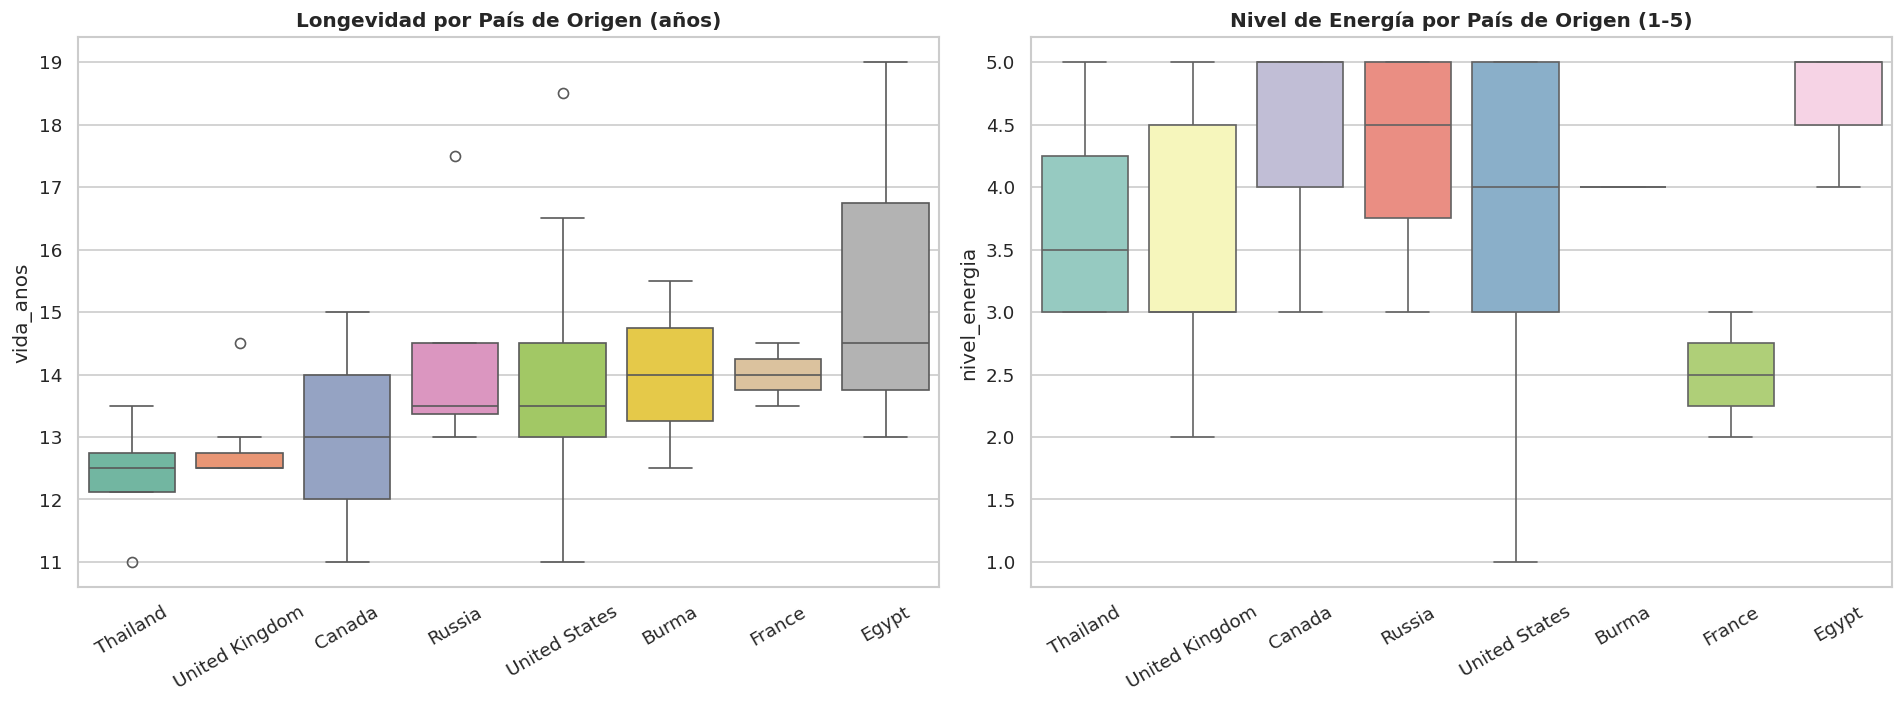

In [6]:
# ── CELDA 6: Boxplots por origen ─────────────────────────────
# Top 8 países con más razas
top_origenes = df_limpio['origen'].value_counts().head(8).index
df_top = df_limpio[df_limpio['origen'].isin(top_origenes)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

orden = df_top.groupby('origen')['vida_anos'].median().sort_values().index

sns.boxplot(data=df_top, x='origen', y='vida_anos', order=orden,
            palette='Set2', ax=axes[0])
axes[0].set_title('Longevidad por País de Origen (años)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_top, x='origen', y='nivel_energia', order=orden,
            palette='Set3', ax=axes[1])
axes[1].set_title('Nivel de Energía por País de Origen (1-5)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/boxplots_origen.png', dpi=150, bbox_inches='tight')
plt.show()

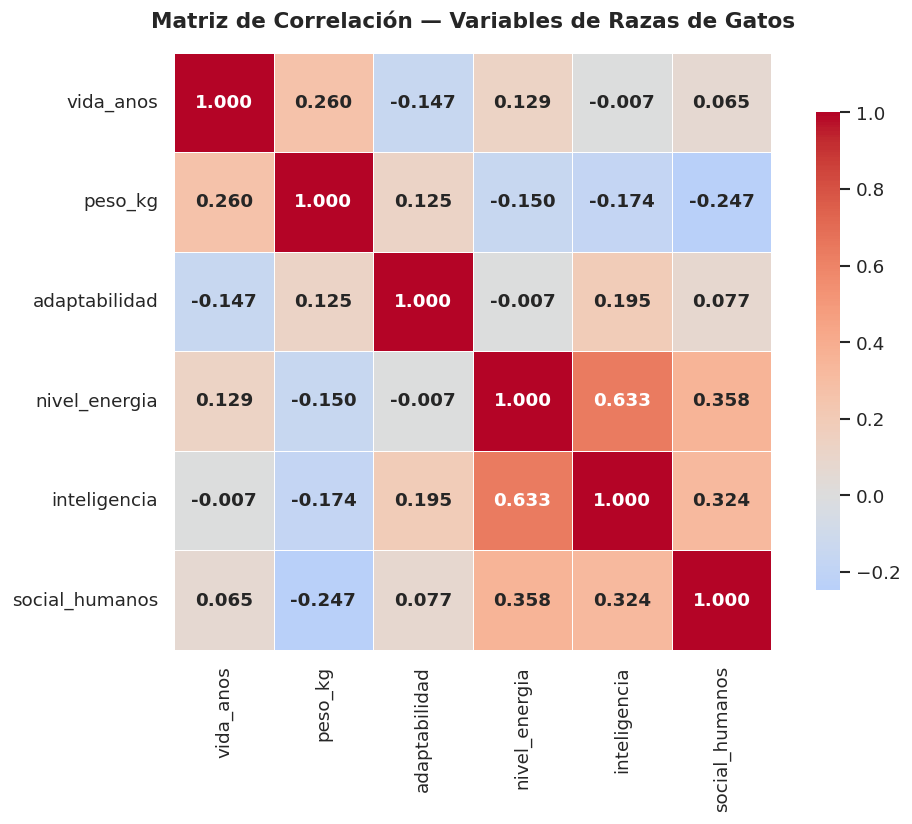


📊 Correlación con vida_anos (ordenada):
peso_kg           0.2597
nivel_energia     0.1294
social_humanos    0.0647
inteligencia     -0.0074
adaptabilidad    -0.1466
Name: vida_anos, dtype: float64


In [7]:
# ── CELDA 7: Matriz de correlación ───────────────────────────
corr = df_limpio[VARS_NUM].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Matriz de Correlación — Variables de Razas de Gatos',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Correlación con vida_anos (ordenada):')
print(corr['vida_anos'].drop('vida_anos').sort_values(ascending=False).round(4))

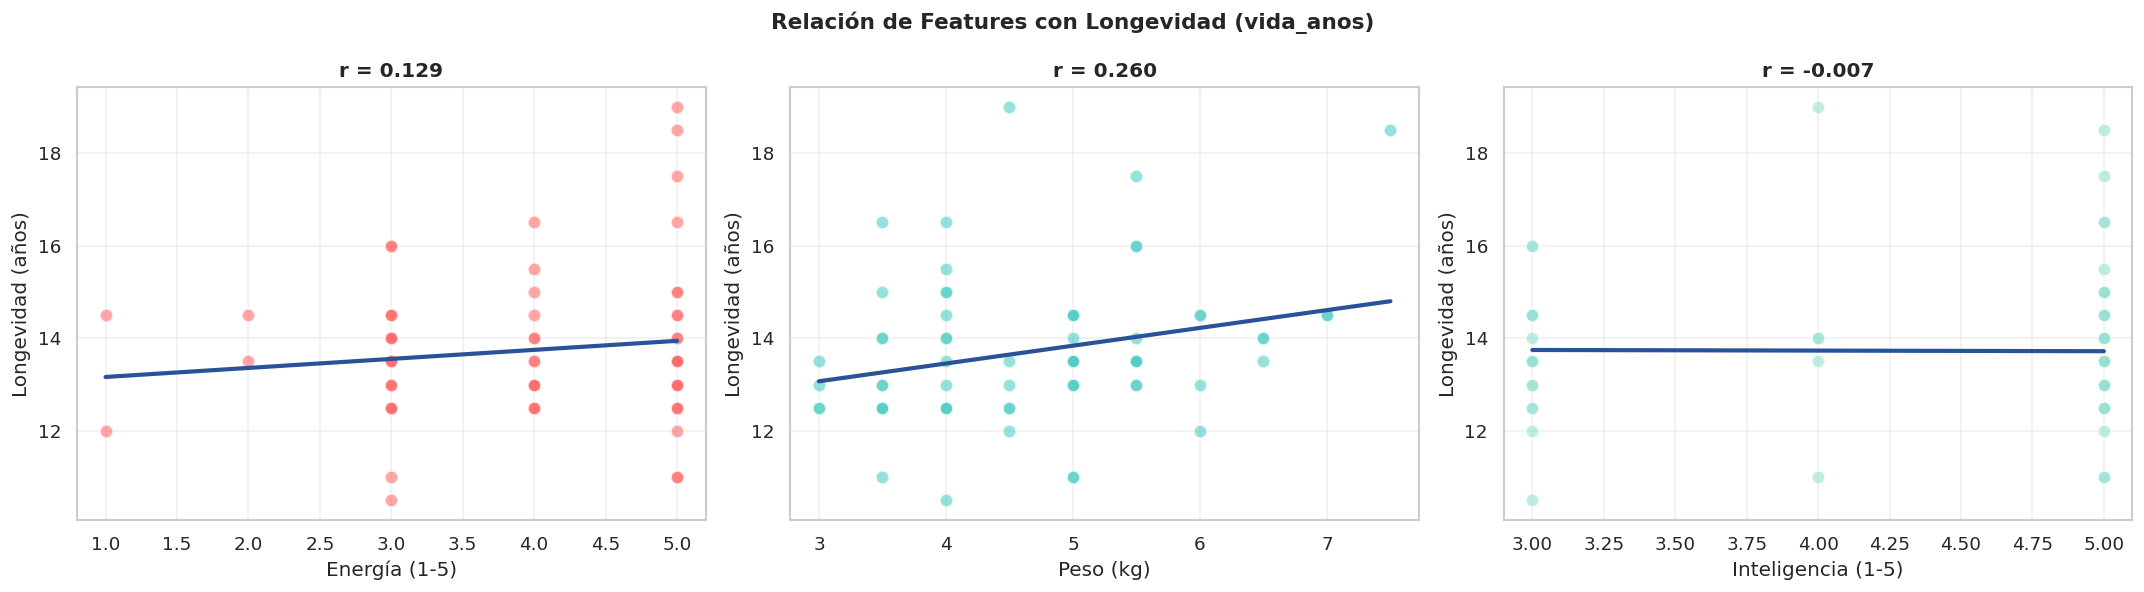

In [8]:
# ── CELDA 8: Scatter plots bivariados ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Features con Longevidad (vida_anos)',
             fontsize=13, fontweight='bold')

pares = [
    ('nivel_energia',  'Energía (1-5)',         '#ff6b6b'),
    ('peso_kg',        'Peso (kg)',              '#4ecdc4'),
    ('inteligencia',   'Inteligencia (1-5)',     '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    ax.scatter(df_limpio[feature], df_limpio['vida_anos'],
               alpha=0.6, s=60, color=color, edgecolors='white')
    # Línea de tendencia
    z = np.polyfit(df_limpio[feature], df_limpio['vida_anos'], 1)
    p = np.poly1d(z)
    xp = np.linspace(df_limpio[feature].min(), df_limpio[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2.5)
    r = df_limpio[[feature, 'vida_anos']].corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Longevidad (años)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/scatter_bivariado.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fase 4: Regresión Lineal Simple
**Objetivo:** predecir `vida_anos` usando únicamente `nivel_energia` como variable independiente.

**Modelo matemático:**
```
ŷ = β₀ + β₁·nivel_energia + ε
```

In [9]:
# ── CELDA 9: Split Train / Test — modelo simple ───────────────
X_simple = df_limpio[['nivel_energia']].values
y        = df_limpio['vida_anos'].values

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f'Train: {X_train_s.shape[0]:,} muestras ({X_train_s.shape[0]/len(y)*100:.0f}%)')
print(f'Test : {X_test_s.shape[0]:,} muestras  ({X_test_s.shape[0]/len(y)*100:.0f}%)')

Train: 52 muestras (79%)
Test : 14 muestras  (21%)


In [10]:
# ── CELDA 10: Entrenamiento modelo simple ─────────────────────
modelo_simple = LinearRegression()
modelo_simple.fit(X_train_s, y_train_s)

y_pred_simple = modelo_simple.predict(X_test_s)

print(f'Intercepto  β₀ : {modelo_simple.intercept_:.4f}')
print(f'Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}')
print(f'\nEcuación: vida_anos = {modelo_simple.intercept_:.3f}'
      f' + {modelo_simple.coef_[0]:.3f} × nivel_energia')

Intercepto  β₀ : 13.0168
Coeficiente β₁ : 0.1847

Ecuación: vida_anos = 13.017 + 0.185 × nivel_energia


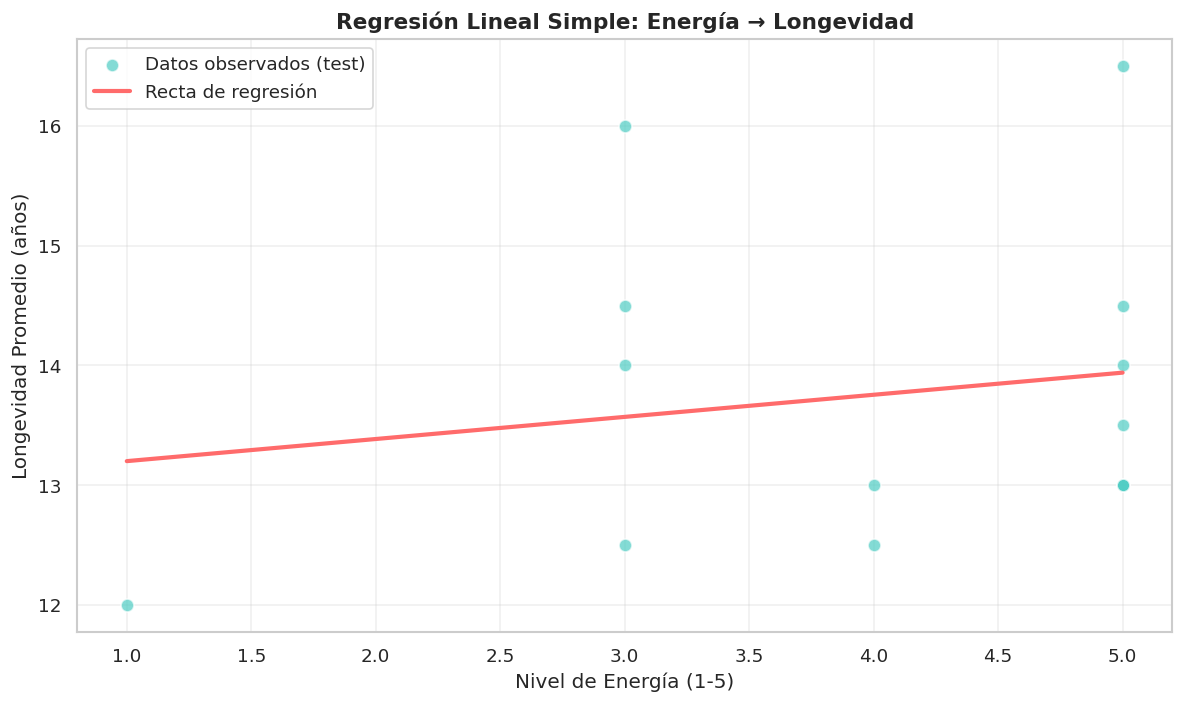

In [11]:
# ── CELDA 11: Recta de regresión ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test_s, y_test_s, alpha=0.7, s=60,
           color='#4ecdc4', edgecolors='white', label='Datos observados (test)')

x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

# Anotar razas extremas
for _, row in df_limpio.nlargest(3, 'vida_anos').iterrows():
    ax.annotate(row['nombre_raza'],
                (row['nivel_energia'], row['vida_anos']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8, color='darkgreen')

ax.set_xlabel('Nivel de Energía (1-5)', fontsize=12)
ax.set_ylabel('Longevidad Promedio (años)', fontsize=12)
ax.set_title('Regresión Lineal Simple: Energía → Longevidad',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/regresion_simple.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────
r2_s   = r2_score(y_test_s, y_pred_simple)
mse_s  = mean_squared_error(y_test_s, y_pred_simple)
rmse_s = np.sqrt(mse_s)
mae_s  = mean_absolute_error(y_test_s, y_pred_simple)

print('=' * 48)
print('    MÉTRICAS — REGRESIÓN LINEAL SIMPLE')
print('=' * 48)
print(f'  R²   (coef. determinación)  : {r2_s:.4f}  ({r2_s*100:.2f}%)')
print(f'  MSE  (error cuadrático med)  : {mse_s:.4f}')
print(f'  RMSE (raíz del MSE)          : {rmse_s:.4f} años')
print(f'  MAE  (error absoluto medio)  : {mae_s:.4f} años')
print('=' * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.0428  (4.28%)
  MSE  (error cuadrático med)  : 1.5286
  RMSE (raíz del MSE)          : 1.2364 años
  MAE  (error absoluto medio)  : 1.0365 años


In [13]:
# ── CELDA 13: OLS statsmodels — resumen completo simple ───────
X_ols_s = sm.add_constant(df_limpio['nivel_energia'])
modelo_ols_simple = sm.OLS(df_limpio['vida_anos'], X_ols_s).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:              vida_anos   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.090
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.300
Time:                        15:54:15   Log-Likelihood:                -123.15
No. Observations:                  66   AIC:                             250.3
Df Residuals:                      64   BIC:                             254.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            12.9679      0.753     17.219

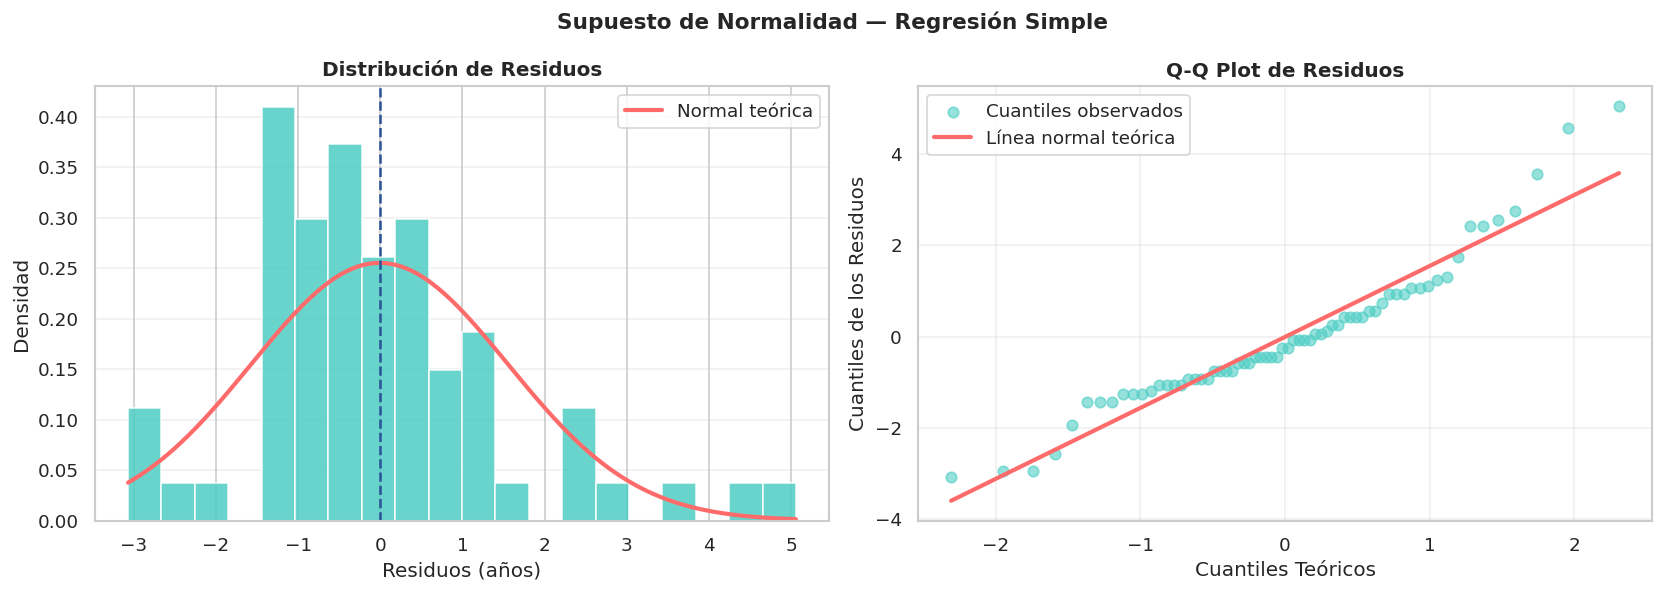


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9375
   p-value       : 0.002423
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)


In [14]:
# ── CELDA 14: Normalidad de residuos — modelo simple ──────────
y_pred_all_s = modelo_simple.predict(df_limpio[['nivel_energia']].values)
residuos_s   = df_limpio['vida_anos'].values - y_pred_all_s

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Simple',
             fontsize=13, fontweight='bold')

# Histograma
axes[0].hist(residuos_s, bins=20, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_s.min(), residuos_s.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_s.mean(), residuos_s.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (años)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos_s, dist='norm')
axes[1].scatter(osm, osr, alpha=0.6, s=40, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/normalidad_simple.png', dpi=150, bbox_inches='tight')
plt.show()

stat_sw_s, p_sw_s = stats.shapiro(residuos_s)
print(f'\n🔬 Test de Shapiro-Wilk:')
print(f'   Estadístico W : {stat_sw_s:.4f}')
print(f'   p-value       : {p_sw_s:.6f}')
if p_sw_s > 0.05:
    print('   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)')
else:
    print('   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)')

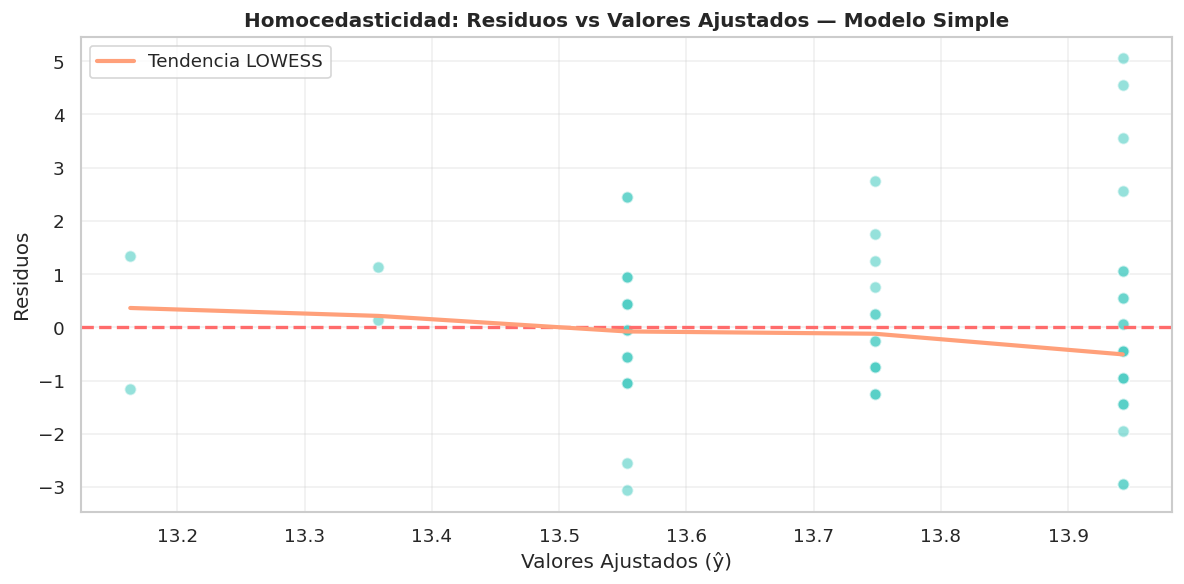


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 3.1405
   p-value        : 0.076370
   Conclusión     : ✅ Homocedasticidad (p > 0.05)


In [15]:
# ── CELDA 15: Homocedasticidad — modelo simple ────────────────
residuos_ols_s  = modelo_ols_simple.resid
ajustados_ols_s = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols_s, residuos_ols_s,
            alpha=0.6, s=50, color='#4ecdc4', edgecolors='white')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_s = sm.nonparametric.lowess(residuos_ols_s, ajustados_ols_s, frac=0.5)
plt.plot(lowess_s[:, 0], lowess_s[:, 1],
         color='#ffa07a', linewidth=2.5, label='Tendencia LOWESS')
plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados — Modelo Simple',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/homoc_simple.png', dpi=150, bbox_inches='tight')
plt.show()

lm_s, lm_p_s, _, _ = het_breuschpagan(residuos_ols_s,
                                        modelo_ols_simple.model.exog)
print(f'\n🔬 Test de Breusch-Pagan (Homocedasticidad):')
print(f'   Estadístico LM : {lm_s:.4f}')
print(f'   p-value        : {lm_p_s:.6f}')
if lm_p_s > 0.05:
    print('   Conclusión     : ✅ Homocedasticidad (p > 0.05)')
else:
    print('   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)')

---
## Fase 5: Regresión Lineal Múltiple
**Objetivo:** predecir `vida_anos` usando `nivel_energia`, `peso_kg`, `inteligencia`, `social_humanos` y `adaptabilidad`.

**Modelo matemático:**
```
ŷ = β₀ + β₁·energia + β₂·peso + β₃·inteligencia + β₄·social + β₅·adaptabilidad + ε
```

In [16]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ───
FEATURES = ['nivel_energia', 'peso_kg', 'inteligencia',
            'social_humanos', 'adaptabilidad']

X_multi = df_limpio[FEATURES].values
y       = df_limpio['vida_anos'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f'Intercepto  β₀              : {modelo_multi.intercept_:.4f}')
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f'Coeficiente {feat:>18} : {coef:.4f}')

Intercepto  β₀              : 11.6970
Coeficiente      nivel_energia : 0.1862
Coeficiente            peso_kg : 0.5968
Coeficiente       inteligencia : 0.0032
Coeficiente     social_humanos : 0.3168
Coeficiente      adaptabilidad : -0.5942


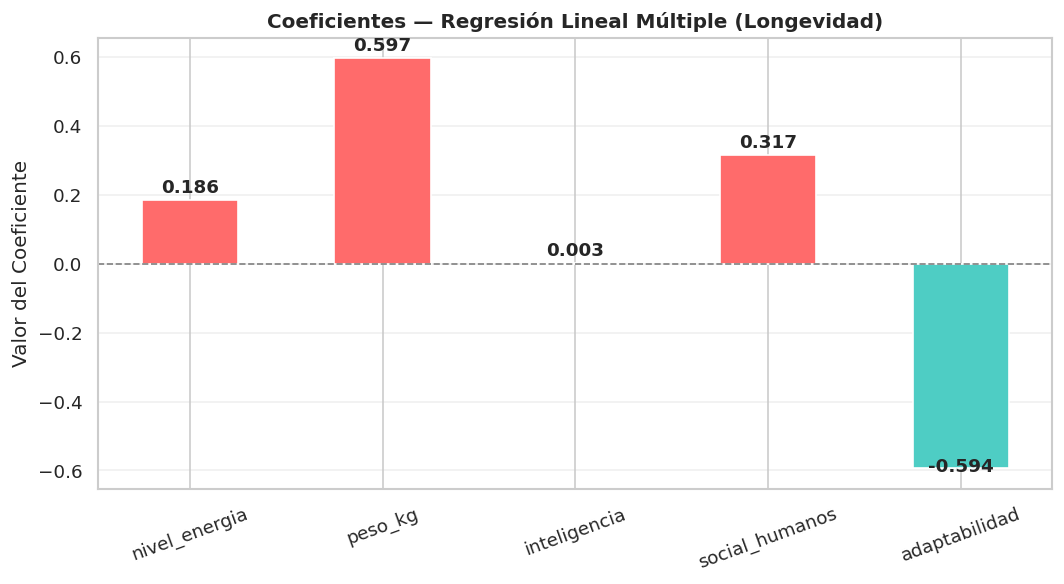


📌 Interpretación:
  Coeficiente positivo → aumenta la longevidad
  Coeficiente negativo → reduce la longevidad


In [17]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple (Longevidad)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')
ax.tick_params(axis='x', rotation=20)

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.01 if coef >= 0 else -0.02
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/coeficientes_multi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Interpretación:')
print('  Coeficiente positivo → aumenta la longevidad')
print('  Coeficiente negativo → reduce la longevidad')

In [18]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────
r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print('=' * 48)
print('  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE')
print('=' * 48)
print(f'  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)')
print(f'  MSE  (error cuadrático med)  : {mse_m:.4f}')
print(f'  RMSE (raíz del MSE)          : {rmse_m:.4f} años')
print(f'  MAE  (error absoluto medio)  : {mae_m:.4f} años')
print('=' * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   (coef. determinación)  : -0.2031  (-20.31%)
  MSE  (error cuadrático med)  : 1.9212
  RMSE (raíz del MSE)          : 1.3861 años
  MAE  (error absoluto medio)  : 1.1709 años


In [19]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ───────────────
X_ols_m = sm.add_constant(df_limpio[FEATURES])
modelo_ols_multi = sm.OLS(df_limpio['vida_anos'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:              vida_anos   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     1.993
Date:                Tue, 07 Apr 2026   Prob (F-statistic):             0.0926
Time:                        15:54:52   Log-Likelihood:                -118.63
No. Observations:                  66   AIC:                             249.3
Df Residuals:                      60   BIC:                             262.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             12.4307      2.070      6.

In [20]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ────────
X_vif = df_limpio[FEATURES].copy()

vif_data = pd.DataFrame({
    'Variable': FEATURES,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
vif_data['VIF']      = vif_data['VIF'].round(3)
vif_data['Criterio'] = vif_data['VIF'].apply(
    lambda v: '✅ Sin multicolinealidad (VIF < 5)'
              if v < 5
              else ('⚠️  Moderada (5 ≤ VIF < 10)'
                    if v < 10
                    else '❌ Severa (VIF ≥ 10)')
)

print('\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)')
print('=' * 60)
print(vif_data.to_string(index=False))
print('=' * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
      Variable    VIF            Criterio
 nivel_energia 26.418 ❌ Severa (VIF ≥ 10)
       peso_kg 18.117 ❌ Severa (VIF ≥ 10)
  inteligencia 46.207 ❌ Severa (VIF ≥ 10)
social_humanos 26.484 ❌ Severa (VIF ≥ 10)
 adaptabilidad 49.730 ❌ Severa (VIF ≥ 10)


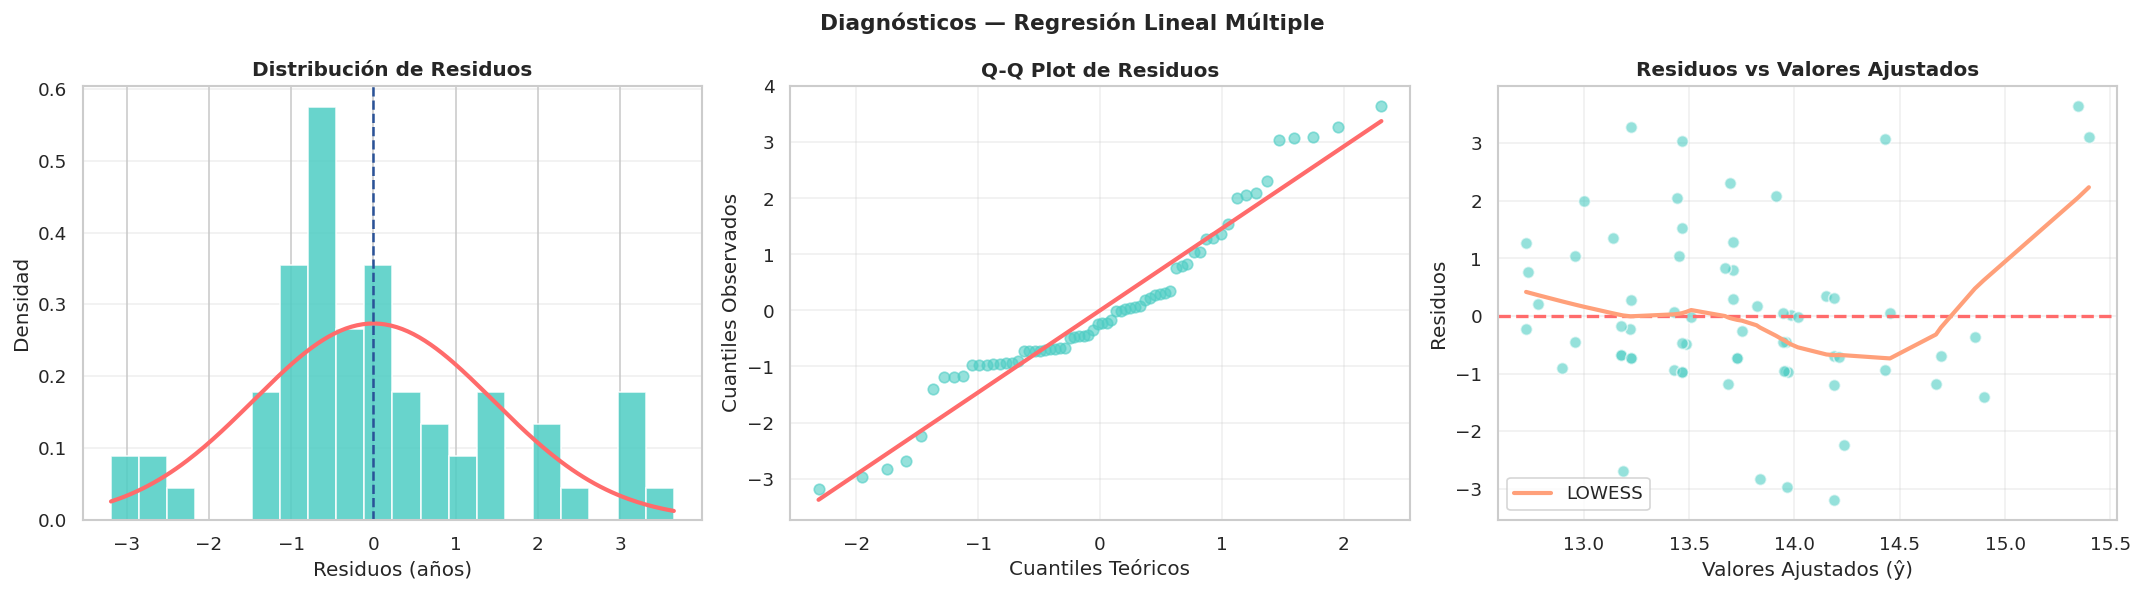


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.006702 → ⚠️  Se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.064694 → ✅ Homocedasticidad OK


In [21]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ────────
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple',
             fontsize=13, fontweight='bold')

# Histograma
axes[0].hist(residuos_m, bins=20, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (años)')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.6, s=40, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.6, s=50, color='#4ecdc4', edgecolors='white')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.5)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/diagnosticos_multi.png', dpi=150, bbox_inches='tight')
plt.show()

# Tests estadísticos
stat_sw_m, p_sw_m = stats.shapiro(residuos_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid,
                                        modelo_ols_multi.model.exog)

print(f'\n🔬 Test Shapiro-Wilk (Normalidad):')
print(f'   p-value: {p_sw_m:.6f} → '
      f'{"✅ No se rechaza normalidad" if p_sw_m > 0.05 else "⚠️  Se rechaza normalidad"}')

print(f'\n🔬 Test Breusch-Pagan (Homocedasticidad):')
print(f'   p-value: {lm_p_m:.6f} → '
      f'{"✅ Homocedasticidad OK" if lm_p_m > 0.05 else "⚠️  Heterocedasticidad detectada"}')

---
## Fase 6: Comparación de Modelos y Conclusiones

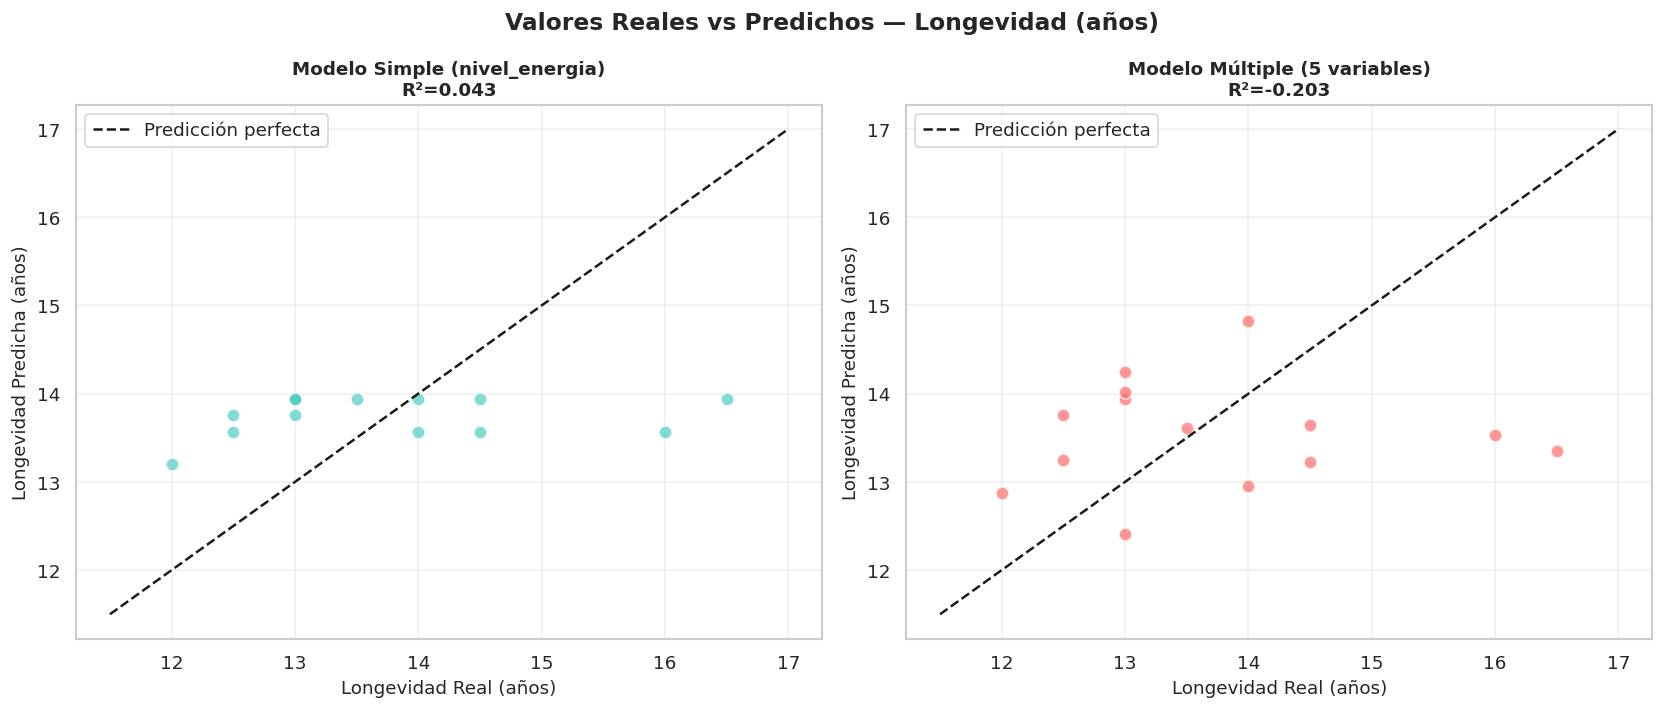

In [22]:
# ── CELDA 22: Reales vs Predichos ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Valores Reales vs Predichos — Longevidad (años)',
             fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, titulo, color, r2) in zip(axes, [
    (y_test_s, y_pred_simple, 'Modelo Simple (nivel_energia)', '#4ecdc4', r2_s),
    (y_test_m, y_pred_multi,  'Modelo Múltiple (5 variables)', '#ff6b6b', r2_m),
]):
    ax.scatter(y_real, y_pred, alpha=0.7, s=60, color=color, edgecolors='white')
    lims = [min(y_real.min(), y_pred.min()) - 0.5,
            max(y_real.max(), y_pred.max()) + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlabel('Longevidad Real (años)', fontsize=11)
    ax.set_ylabel('Longevidad Predicha (años)', fontsize=11)
    ax.set_title(f'{titulo}\nR²={r2:.3f}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/reales_vs_predichos.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── CELDA 23: Tabla comparativa final ────────────────────────
resumen = pd.DataFrame([
    {
        'Modelo':    'Regresión Simple',
        'Objetivo':  'vida_anos',
        'Variables': 'nivel_energia',
        'R²':        round(r2_s,  4),
        'MAE':       round(mae_s, 4),
        'RMSE':      round(rmse_s, 4),
    },
    {
        'Modelo':    'Regresión Múltiple',
        'Objetivo':  'vida_anos',
        'Variables': '5 variables',
        'R²':        round(r2_m,  4),
        'MAE':       round(mae_m, 4),
        'RMSE':      round(rmse_m, 4),
    },
])

print('=' * 65)
print('RESUMEN COMPARATIVO DE MODELOS — LONGEVIDAD DE RAZAS')
print('=' * 65)
print(resumen.to_string(index=False))
print('=' * 65)
print('\n📌 Conclusiones:')
print('  - R² cercano a 1.0 indica mejor ajuste del modelo')
print('  - MAE indica el error promedio en años de vida')
print('  - RMSE penaliza más los errores grandes')
print('  - El modelo múltiple debería superar al simple')

RESUMEN COMPARATIVO DE MODELOS — LONGEVIDAD DE RAZAS
            Modelo  Objetivo     Variables      R²    MAE   RMSE
  Regresión Simple vida_anos nivel_energia  0.0428 1.0365 1.2364
Regresión Múltiple vida_anos   5 variables -0.2031 1.1709 1.3861

📌 Conclusiones:
  - R² cercano a 1.0 indica mejor ajuste del modelo
  - MAE indica el error promedio en años de vida
  - RMSE penaliza más los errores grandes
  - El modelo múltiple debería superar al simple


In [24]:
# ── CELDA 24: Predicción para una nueva raza ─────────────────
nueva_raza = pd.DataFrame([{
    'nivel_energia':  4,
    'peso_kg':        4.5,
    'inteligencia':   5,
    'social_humanos': 4,
    'adaptabilidad':  3
}])

vida_predicha = modelo_multi.predict(nueva_raza[FEATURES])[0]

print('🔮 PREDICCIÓN PARA NUEVA RAZA HIPOTÉTICA')
print('=' * 45)
print('Características ingresadas:')
for col, val in nueva_raza.iloc[0].items():
    print(f'  {col:<20} {val}')
print()
print(f'📅 Longevidad predicha      : {vida_predicha:.1f} años')
print(f'📊 Promedio real en dataset : {df_limpio["vida_anos"].mean():.1f} años')
print(f'📊 Mínimo real              : {df_limpio["vida_anos"].min():.1f} años')
print(f'📊 Máximo real              : {df_limpio["vida_anos"].max():.1f} años')

🔮 PREDICCIÓN PARA NUEVA RAZA HIPOTÉTICA
Características ingresadas:
  nivel_energia        4.0
  peso_kg              4.5
  inteligencia         5.0
  social_humanos       4.0
  adaptabilidad        3.0

📅 Longevidad predicha      : 14.6 años
📊 Promedio real en dataset : 13.7 años
📊 Mínimo real              : 10.5 años
📊 Máximo real              : 19.0 años


/home/omareiza-2023/Documentos/etl-cats/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
